Imię: 

Nazwisko: 

Indeks: 

Grupa: 

**Uwaga 1: Przed wysłaniem pliku uruchom po kolei (od góry do dołu) wszystkie komórki z kodem. Niniejszy plik należy przesłać z uruchomionymi komórkami.**

Uwaga 2: Pierwszych pięć zadań rozwiąż po kolei (tj. zgodnie z ich numeracją). Należy w nich wykorzystać zbiór danych zawierający informacje na temat diamentów. Każdy z diamentów jest opisany za pomocą następujących zmiennych:
- `carat` - masa kamienia (ct)
- `cut` - szlif kamienia
- `color` - barwa kamienia
- `clarity` - czystość kamienia
- `depth` - stosunek wysokości kamienia do średniej arytmetycznej z długości i szerokości kamienia (%)
- `table` - stosunek szerokości tafli do szerokości kamienia (%)
- `price` - cena (USD)
- `x` - długość kamienia (mm)
- `y` - szerokość kamienia (mm)
- `z` - wysokość kamienia (mm)

**Zadanie. 1.** Zapoznanie się ze zbiorem danych. Wykonaj poniższe polecenia.
1. Zaimportuj moduł `pandas` z aliasem `pd`.
2. Skopiuj plik `diamonds-dirty.csv` do katalogu, w którym znajduje się aktualnie używany notatnik Jupyter.
3. Wczytaj dane z pliku csv jako ramkę danych i przypisz ją do zmiennej `dane`. Wyświetl pięć pierwszych wierszy tej ramki danych.
4. Za pomocą odpowiedniego atrybutu sprawdź, ile wierszy i kolumn ma ramka danych.
5. Za pomocą odpowiedniego atrybutu sprawdź, jakie są typy danych w poszczególnych kolumnach.
6. Wykorzystując odpowiednią metodę, wyświetl podstawowe charakterystyki liczbowe dla zmiennych ilościowych i jakościowych.

***Rozwiązanie:***

Ad. 1.

In [2]:
import pandas as pd

Ad. 3.

In [5]:
dane = pd.read_csv("diamonds-dirty.csv")

In [6]:
print(dane.head())

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


Ad. 4.

In [11]:
l_wierszy, l_kolumn = dane.shape
print(f'Liczba_wierszy: {l_wierszy}, Liczba kolumn: {l_kolumn}')

Liczba_wierszy: 53940, Liczba kolumn: 10


Ad. 5.

In [14]:
t_danych = dane.dtypes
print(t_danych)

carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object


Ad. 6.

In [16]:
ch_liczbowe = dane.describe(include='all')
print(ch_liczbowe)

               carat    cut  color clarity         depth         table  \
count   53925.000000  53936  53919   53940  53940.000000  53940.000000   
unique           NaN      5      7       8           NaN           NaN   
top              NaN  Ideal      G     SI1           NaN           NaN   
freq             NaN  21551  11271   13065           NaN           NaN   
mean        0.797958    NaN    NaN     NaN     61.749405     57.457184   
std         0.474071    NaN    NaN     NaN      1.432621      2.234491   
min         0.200000    NaN    NaN     NaN     43.000000     43.000000   
25%         0.400000    NaN    NaN     NaN     61.000000     56.000000   
50%         0.700000    NaN    NaN     NaN     61.800000     57.000000   
75%         1.040000    NaN    NaN     NaN     62.500000     59.000000   
max         5.010000    NaN    NaN     NaN     79.000000     95.000000   

               price             x             y             z  
count   53940.000000  53940.000000  53940.0000

**Zadanie. 2.** Wykrywanie i rozwiązywanie problemu brakujących danych. Wykonaj poniższe polecenia.
1. Zidentyfikuj kolumny, które zawierają brakujące dane. Ile wartości brakujących występuje w każdej takiej kolumnie?
2. Usuń te wiersze ramki danych (modyfikując oryginalną ramkę danych), które zawierają wartości brakujące w kolumnie `cut`. Sprawdź liczbę wierszy, które pozostały (spodziewana liczba wierszy, które zostaną to 53936).
3. Uzupełnij medianą brakujące dane w kolumnie `carat` (modyfikując oryginalną ramkę danych). Sprawdź, czy kolumna `carat` rzeczywiście nie zawiera już brakujących wartości.
4. Uzupełnij najczęściej występującą kategorią brakujące dane w kolumnie `color` (modyfikując oryginalną ramkę danych). Sprawdź, czy kolumna `color` rzeczywiście nie zawiera już brakujących wartości.

***Rozwiązanie:***

Ad. 1.

In [17]:
missed_data = dane.isnull().sum()
missed_columns = missed_data[missed_data > 0]
print(missed_columns)

carat    15
cut       4
color    21
dtype: int64


Ad. 2.

In [20]:
dane = dane.dropna(subset=['cut'])
l_w_p_usunieciu = dane.shape[0]
print(f"Liczba wierszy po usunieciu brakujacych wartosci w kolumnie 'cut': {l_w_p_usunieciu}")

Liczba wierszy po usunieciu brakujacych wartosci w kolumnie 'cut': 53936


Ad. 3.

In [24]:
mediana_carat = dane['carat'].median()
dane['carat'] = dane['carat'].fillna(mediana_carat)
is_carat_empty = dane['carat'].isnull().sum()
print(is_carat_empty)

0


Ad. 4.

In [29]:
col_with_most_occur = dane['color'].mode()[0]
dane['color'] = dane['color'].fillna(col_with_most_occur)
is_col_empty = dane['color'].isnull().sum()
print(is_col_empty)

0


       carat        cut color clarity  depth  table  price     x     y     z
0       0.23      Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1       0.21    Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2       0.23       Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3       0.29    Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4       0.31       Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
...      ...        ...   ...     ...    ...    ...    ...   ...   ...   ...
53935   0.72      Ideal     D     SI1   60.8   57.0   2757  5.75  5.76  3.50
53936   0.72       Good     D     SI1   63.1   55.0   2757  5.69  5.75  3.61
53937   0.70  Very Good     D     SI1   62.8   60.0   2757  5.66  5.68  3.56
53938   0.86    Premium     H     SI2   61.0   58.0   2757  6.15  6.12  3.74
53939   0.75      Ideal     D     SI2   62.2   55.0   2757  5.83  5.87  3.64

[53936 rows x 10 columns]


**Zadanie. 3.** Wykrywanie i rozwiązywanie problemu wartości odstających (1/2). Wykonaj poniższe polecenia.
1. Zaimportuj moduły `matplotlib.pyplot` (z aliasem `plt`), `seaborn` (z aliasem `sns`) i `numpy` (z aliasem `np`).
2. Przedstaw graficznie rozkład masy diamentów (zmienna `carat`). Sporządź w tym celu histogram liczebności. Co możesz powiedzieć o rozkładzie tej zmiennej?
3. Sporządź wykres pudełkowy dla zmiennej `carat`. Co na podstawie tego wykresu możesz powiedzieć o wartościach odstających?
4. Dodaj do ramki danych nową kolumnę (nazwij ją `log_carat`) zawierającą logarytm naturalny masy diamentów. Sprawdź, czy w ramce danych kolumna `log_carat` rzeczywiście została utworzona.
5. Sporządź wykres pudełkowy dla zmiennej `log_carat`. Jaki wpływ na wartości odstające ma logarytmowanie masy diamentów?
6. Usuń kolumnę `carat` z ramki danych (modyfikując oryginalną ramkę danych). Sprawdź, czy zmienna `carat` rzeczywiście została usunięta.

***Rozwiązanie:***

Ad. 1.

In [32]:
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

Ad. 2.

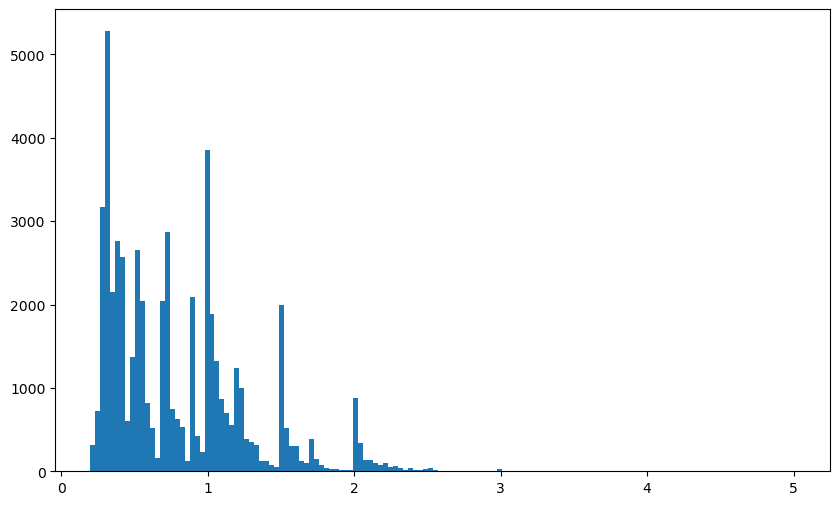

In [41]:
plt.figure(figsize=(10, 6))
plt.hist(dane['carat'], bins='auto')
plt.show()

Mozna zauwazyc, ze im ciezszy diament, tym jest mniej tych diamentow. Dla wiekszych diamentow zauwazalna jest nadrepretzentacja diamentow o masie 1, 1.5, 2 karaty

Ad. 3.

{'whiskers': [<matplotlib.lines.Line2D at 0x146293950>,
 'caps': [<matplotlib.lines.Line2D at 0x1462cae90>,
 'boxes': [<matplotlib.lines.Line2D at 0x146290b90>],
 'medians': [<matplotlib.lines.Line2D at 0x1462cbad0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1462cfe50>],
 'means': []}

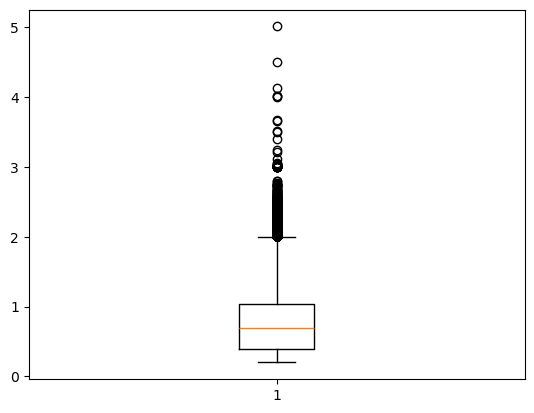

In [43]:
plt.boxplot(dane['carat'])

Mozna stwierdzic duza liczbe odstajacych wartosci (W gore)

Ad. 4.

In [45]:
dane['log_carat'] = np.log(dane['carat'])
print(dane)

       carat        cut color clarity  depth  table  price     x     y     z  \
0       0.23      Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43   
1       0.21    Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31   
2       0.23       Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31   
3       0.29    Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63   
4       0.31       Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75   
...      ...        ...   ...     ...    ...    ...    ...   ...   ...   ...   
53935   0.72      Ideal     D     SI1   60.8   57.0   2757  5.75  5.76  3.50   
53936   0.72       Good     D     SI1   63.1   55.0   2757  5.69  5.75  3.61   
53937   0.70  Very Good     D     SI1   62.8   60.0   2757  5.66  5.68  3.56   
53938   0.86    Premium     H     SI2   61.0   58.0   2757  6.15  6.12  3.74   
53939   0.75      Ideal     D     SI2   62.2   55.0   2757  5.83  5.87  3.64   

       log_carat  
0      -1.469676  
1

Ad. 5.

{'whiskers': [<matplotlib.lines.Line2D at 0x146349290>,
 'caps': [<matplotlib.lines.Line2D at 0x14634ab10>,
 'boxes': [<matplotlib.lines.Line2D at 0x146348910>],
 'medians': [<matplotlib.lines.Line2D at 0x14634bfd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x146354b10>],
 'means': []}

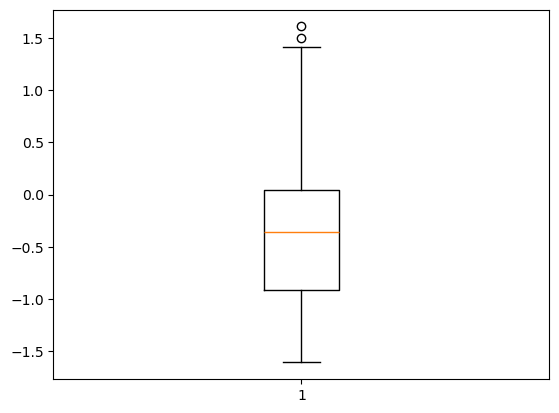

In [46]:
plt.boxplot(dane['log_carat'])

Wasy maja wieksza rozpietosc, ale jest zdecydowanie mniej wartosci odstajacych

Ad. 6.

In [47]:
dane.drop(columns=['carat'], inplace=True)
print(dane)

             cut color clarity  depth  table  price     x     y     z  \
0          Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43   
1        Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31   
2           Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31   
3        Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63   
4           Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75   
...          ...   ...     ...    ...    ...    ...   ...   ...   ...   
53935      Ideal     D     SI1   60.8   57.0   2757  5.75  5.76  3.50   
53936       Good     D     SI1   63.1   55.0   2757  5.69  5.75  3.61   
53937  Very Good     D     SI1   62.8   60.0   2757  5.66  5.68  3.56   
53938    Premium     H     SI2   61.0   58.0   2757  6.15  6.12  3.74   
53939      Ideal     D     SI2   62.2   55.0   2757  5.83  5.87  3.64   

       log_carat  
0      -1.469676  
1      -1.560648  
2      -1.469676  
3      -1.237874  
4      -1.171183  
...      

**Zadanie. 4.** Wykrywanie i rozwiązywanie problemu wartości odstających (2/2). Wykonaj poniższe polecenia.
1. Sporządź wykres pudełkowy dla zmiennej `table`. Co na podstawie tego wykresu możesz powiedzieć o wartościach odstających?
2. Zidentyfikuj liczbę wartości odstających dla zmiennej `table`, kierując się kryterium Tukeya i przyjmując współczynnik odległości na poziomie 1,5 (spodziewana liczba wartości odstających to 605). W tym celu wyznacz końce przedziału z kryterium Tukeya i w odpowiedni sposób wykorzystaj je aby wykryć wartości odstające, a następnie zlicz te wartości.
3. Zmodyfikuj oryginalną ramkę danych, zastępując wartości odstające zmiennej `table` jednym z końców przedziału z kryterium Tukeya, bliższym zastępowanej wartości.
4. Ponownie sporządź wykres pudełkowy dla zmiennej `table`. Co na podstawie tego wykresu możesz tym razem powiedzieć o wartościach odstających?

***Rozwiązanie:***

Ad. 1.

{'whiskers': [<matplotlib.lines.Line2D at 0x14639d2d0>,
 'caps': [<matplotlib.lines.Line2D at 0x1463afc90>,
 'boxes': [<matplotlib.lines.Line2D at 0x1463ad990>],
 'medians': [<matplotlib.lines.Line2D at 0x1463b5290>],
 'fliers': [<matplotlib.lines.Line2D at 0x1463b5e10>],
 'means': []}

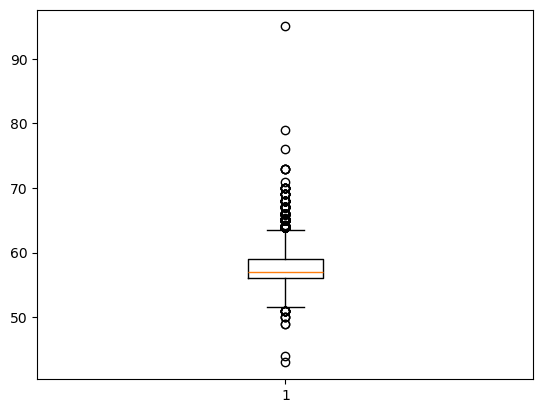

In [48]:
plt.boxplot(dane['table'])

Wartosci odstaja w gore i jest ich duzo

In [58]:
print(dane.dtypes)

cut           object
color         object
clarity       object
depth        float64
table        float64
price          int64
x            float64
y            float64
z            float64
log_carat    float64
dtype: object


Ad. 2.

In [64]:
Q1 = np.percentile(dane['table'], 25)
Q3 = np.percentile(dane['table'], 75)
IQR = Q3 - Q1
dol = Q1 - 1.5 * IQR
gora = Q3 + 1.5 * IQR
odstajace = dane[(dane['table'] < dol) | (dane['table'] > gora)]
l_dan_odst = odstajace.shape[0]
print(l_dan_odst)



605


Ad. 3.

In [65]:
dane.loc[dane['table'] < dol, 'table'] = dol
dane.loc[dane['table'] > gora, 'table'] = gora
print(dane)

             cut color clarity  depth  table  price     x     y     z  \
0          Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43   
1        Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31   
2           Good     E     VS1   56.9   63.5    327  4.05  4.07  2.31   
3        Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63   
4           Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75   
...          ...   ...     ...    ...    ...    ...   ...   ...   ...   
53935      Ideal     D     SI1   60.8   57.0   2757  5.75  5.76  3.50   
53936       Good     D     SI1   63.1   55.0   2757  5.69  5.75  3.61   
53937  Very Good     D     SI1   62.8   60.0   2757  5.66  5.68  3.56   
53938    Premium     H     SI2   61.0   58.0   2757  6.15  6.12  3.74   
53939      Ideal     D     SI2   62.2   55.0   2757  5.83  5.87  3.64   

       log_carat  
0      -1.469676  
1      -1.560648  
2      -1.469676  
3      -1.237874  
4      -1.171183  
...      

Ad. 4.

{'whiskers': [<matplotlib.lines.Line2D at 0x1514cee50>,
 'caps': [<matplotlib.lines.Line2D at 0x1514d0290>,
 'boxes': [<matplotlib.lines.Line2D at 0x1507c1990>],
 'medians': [<matplotlib.lines.Line2D at 0x1514d1610>],
 'fliers': [<matplotlib.lines.Line2D at 0x1514d21d0>],
 'means': []}

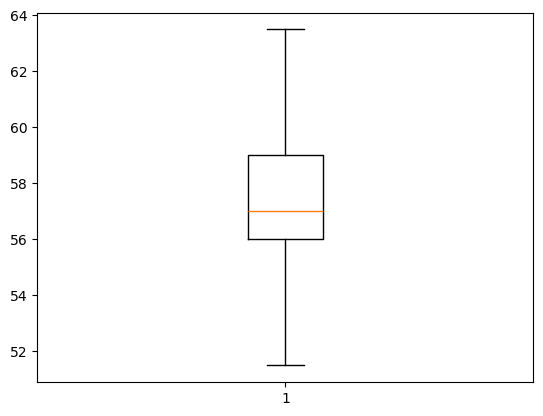

In [66]:
plt.boxplot(dane['table'])

Danych odstajacych brak w tym wypadku

**Zadanie. 5.** Standaryzacja zmiennych oraz transformacja zmiennych jakościowych do postaci numerycznej. Wykonaj poniższe polecenia.
1. Zaimportuj `StandardScaler` z modułu `sklearn.preprocessing`. Przeprowadź standaryzację zmiennej `depth`. Nadpisz wartości zmiennej `depth` wartościami zestandaryzowanymi i upewnij się, że w ramce danych do takiego nadpisania rzeczywiście doszło.
2. Dla zmiennych opisujących barwę diamentu (zmienna `color`) i jego czystość (zmienna `clarity`) wyświetl wszystkie unikalne kategorie wraz z liczbą ich wystąpień w zbiorze danych.
3. Utwórz zmienne sztuczne dla zmiennych `color` i `clarity`, modyfikując oryginalną ramkę danych. Wygeneruj tyle zmiennych sztucznych, ile unikalnych kategorii posiada dana zmienna. Sprawdź, czy zmienne sztuczne rzeczywiście zostały utworzone.

***Rozwiązanie:***

Ad. 1.

In [83]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
dane['depth'] = scaler.fit_transform(dane[['depth']])
print(dane['depth'])
print(dane['depth'].max())
print(dane['depth'].min())


0       -0.174092
1       -1.360738
2       -3.385019
3        0.454133
4        1.082358
           ...   
53935   -0.662711
53936    0.942753
53937    0.733344
53938   -0.523105
53939    0.314528
Name: depth, Length: 53940, dtype: float64
12.041392087719215
-13.087602738397587


In [84]:
avg_depth = dane['depth'].mean()
std_depth = dane['depth'].std()
print(avg_depth)
print(std_depth)

-3.996901684915269e-15
1.000009269687676


Ad. 2.

In [90]:
print(dane['color'].value_counts())
print(dane['clarity'].value_counts())

color
 3    11271
 1     9797
 2     9542
 4     8304
 0     6775
 5     5422
 6     2808
-1       21
Name: count, dtype: int64
clarity
2    13065
5    12258
3     9194
4     8171
7     5066
6     3655
1     1790
0      741
Name: count, dtype: int64


In [93]:
dane = pd.read_csv('diamonds-dirty.csv')
dane = pd.get_dummies(dane, columns=['color', 'clarity'], drop_first=True)
print(dane.head())

   carat      cut  depth  table  price     x     y     z  color_E  color_F  \
0   0.23    Ideal   61.5   55.0    326  3.95  3.98  2.43     True    False   
1   0.21  Premium   59.8   61.0    326  3.89  3.84  2.31     True    False   
2   0.23     Good   56.9   65.0    327  4.05  4.07  2.31     True    False   
3   0.29  Premium   62.4   58.0    334  4.20  4.23  2.63    False    False   
4   0.31     Good   63.3   58.0    335  4.34  4.35  2.75    False    False   

   ...  color_H  color_I  color_J  clarity_IF  clarity_SI1  clarity_SI2  \
0  ...    False    False    False       False        False         True   
1  ...    False    False    False       False         True        False   
2  ...    False    False    False       False        False        False   
3  ...    False     True    False       False        False        False   
4  ...    False    False     True       False        False         True   

   clarity_VS1  clarity_VS2  clarity_VVS1  clarity_VVS2  
0        False        

Ad. 3.

In [3]:

dane = pd.read_csv('diamonds-dirty.csv')
dane['color'] = pd.Categorical(dane['color']).codes
dane['clarity'] = pd.Categorical(dane['clarity']).codes
print(dane.head())

   carat      cut  color  clarity  depth  table  price     x     y     z
0   0.23    Ideal      1        3   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium      1        2   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good      1        4   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium      5        5   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good      6        3   63.3   58.0    335  4.34  4.35  2.75


**Zadanie. 6.** Napisz program, który będzie prostym kalkulatorem umożliwiającym wykonywanie czterech podstawowych działań arytmetycznych: dodawanie, odejmowanie, mnożenie i dzielenie. Program ten:
1. Poprosi użytkownika o podanie pierwszej liczby (dla uproszczenia załóż, że użytkownik zawsze poda poprawną wartość będącą liczbą).
2. Poprosi użytkownika o podanie operacji arytmetycznej (dla uproszczenia załóż, że użytkownik zawsze poda jeden z czterech znaków: `+`, `-`, `*`, `/`, który będzie wskazywał na wybrane przez użytkownika działanie arytmetyczne).
3. Poprosi użytkownika o podanie drugiej liczby (dla uproszczenia załóż, że użytkownik zawsze poda poprawną wartość będącą liczbą).
4. Wyświetli wynik wykonanego działania w postaci następującej informacji: `Otrzymany wynik to <rezultat>`, przy czym w miejscu `<rezultat>` ma się pojawić uzyskany wynik dodawania, odejmowania, mnożenia, albo dzielenia liczb.
5. Sprawdź poprawność działania programu, uruchamiając go czterokrotnie i podając za każdym razem inne działanie arytmetyczne.

***Rozwiązanie:***

In [95]:
def kalkulator():
    pierwsza_liczba = float(input("Podaj pierwszą liczbę: "))
    operacja = input("Podaj operację (+, -, *, /): ")
    druga_liczba = float(input("Podaj drugą liczbę: "))

    if operacja == '+':
        wynik = pierwsza_liczba + druga_liczba
    elif operacja == '-':
        wynik = pierwsza_liczba - druga_liczba
    elif operacja == '*':
        wynik = pierwsza_liczba * druga_liczba
    elif operacja == '/':
        wynik = pierwsza_liczba / druga_liczba
    else:
        print("Niepoprawna operacja!")
        return

    print(f"Otrzymany wynik to {wynik}")


for _ in range(4):
    kalkulator()

Otrzymany wynik to 13.0
Niepoprawna operacja!
Otrzymany wynik to 18.0
Otrzymany wynik to 7.166666666666667


**Zadanie. 7.** Rozważamy równanie kwadratowe $ax^2+bx+c=0,$ gdzie $a,b$ i $c$ to współczynniki, przy czym $a\neq0$ oraz $a,b,c\in{R}.$

Napisz funkcję, która będzie zwracać liczbę pierwiastków (tj. rozwiązań) równania kwadratowego w zbiorze liczb rzeczywistych, a następnie sprawdź poprawność działania tej funkcji. W tym celu wykonaj poniższe polecenia.
1. Napisz funkcję `liczba_pierwiastkow()`, która będzie miała trzy parametry: `a`, `b` i `c` (są to współczynniki odpowiednio $a,b$ i $c$ występujące w równaniu kwadratowym). Funkcja ma zwracać wartość `0`, `1`, albo `2`, w zależności od liczby pierwiastków (rozwiązań) równania kwadratowego (podpowiedź: należy obliczyć wyróżnik $\Delta=b^2-4ac,$ którego wartość wskazuje na liczbę pierwiastków równania kwadratowego).
2. Sprawdź poprawność działania napisanej funkcji, wywołując ją z następującymi przykładowymi argumentami:
    - `a=-1`, `b=8`, `c=-16` (spodziewana wartość zwrócona przez funkcję: `1`),
    - `a=4`, `b=-7`, `c=-2` (spodziewana wartość zwrócona przez funkcję: `2`),
    - `a=2`, `b=-6`, `c=18` (spodziewana wartość zwrócona przez funkcję: `0`).

***Rozwiązanie:***

In [97]:
def liczba_pierwiastkow(a, b, c):
    delta = b**2 - 4*a*c
    if delta > 0:
        return 2
    elif delta == 0:
        return 1
    else:
        return 0

test_f = [
    (-1, 8, -16), 
    (4, -7, -2),   
    (2, -6, 18)    
]

for idx, (a, b, c) in enumerate(test_cases, start=1):
    wynik = liczba_pierwiastkow(a, b, c)
    print(f"Test {idx}: Dla a={a}, b={b}, c={c}, liczba pierwiastków: {wynik}")

Test 1: Dla a=-1, b=8, c=-16, liczba pierwiastków: 1
Test 2: Dla a=4, b=-7, c=-2, liczba pierwiastków: 2
Test 3: Dla a=2, b=-6, c=18, liczba pierwiastków: 0


In [101]:

def liczba_pierwiastkow(a, b, c):
    delta = b ** 2 - 4 * a * c
    if delta > 0:
        return 2
    elif delta == 0:
        return 1
    else:
        return 0

a = -1
b = 8
c = -16
result = liczba_pierwiastkow(a, b, c)
print("Test 1: Dla a=-1, b=8, c=-16 liczba pierwiastków wynosi", result)

a = 4
b = -7
c = -2
result = liczba_pierwiastkow(a, b, c)
print("Test 2: Dla a=4, b=-7, c=-2 liczba pierwiastków wynosi", result)


a = 2
b = -6
c = 18
result = liczba_pierwiastkow(a, b, c)
print("Test 3: Dla a=2, b=-6, c=18 liczba pierwiastków wynosi", result)

Test 1: Dla a=-1, b=8, c=-16 liczba pierwiastków wynosi 1
Test 2: Dla a=4, b=-7, c=-2 liczba pierwiastków wynosi 2
Test 3: Dla a=2, b=-6, c=18 liczba pierwiastków wynosi 0
